In [152]:
from pathlib import Path

try:
    import kagglesdk.kaggle_env as kaggle_env

    if not hasattr(kaggle_env, "get_web_endpoint"):
        kaggle_env.get_web_endpoint = kaggle_env.get_endpoint
except ImportError:
    pass

import kagglehub
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PolynomialFeatures,
    RobustScaler,
    StandardScaler,
    FunctionTransformer,
)
from sklearn.impute import SimpleImputer

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


In [153]:
class TotalSpendingRegressor:
    def __init__(self):
        self.figure_dir = Path("figures")
        self.result_dir = Path("results")
        self.raw_df = self.load_dataset_from_kaggle()


    def load_dataset_from_kaggle(self):
        """
        Load Customer Personality Analysis dataset.
        Kaggle original file is a CSV-like text file.
        """
        path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")
        df = pd.read_csv(path + '/marketing_campaign.csv', sep='\t')
        return df.copy()
    def preprocessing(self):
        temp_df = self.create_features(self.raw_df)
        self.df = self.clean_data(temp_df)

    def save_and_show_plot(self, filename):
        """
        Save the current matplotlib figure to the figures directory and show it.
        """
        self.figure_dir.mkdir(exist_ok=True)
        safe_filename = "".join(
            char.lower() if char.isalnum() else "_"
            for char in filename
        ).strip("_")
        figure_path = self.figure_dir / f"{safe_filename}.png"
        plt.savefig(figure_path, dpi=300, bbox_inches="tight")
        print(f"Saved figure: {figure_path}")
        plt.show()
        plt.close()

    def create_features(self, df):
        """
        Create derived variables according to the team proposal.
        """
        df = df.copy()

        df["Dt_Customer"] = pd.to_datetime(
            df["Dt_Customer"],
            format="%d-%m-%Y",
            errors="coerce"
        )

        # Create Age from Year_Birth.
        df["Age"] = 2014 - df["Year_Birth"]

        # Customer tenure in days.
        reference_date = df["Dt_Customer"].max()
        df["Customer_Days"] = (reference_date - df["Dt_Customer"]).dt.days

        # Family-related feature.
        df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

        # Total spending from six product spending columns.
        spending_cols = [
            "MntWines",
            "MntFruits",
            "MntMeatProducts",
            "MntFishProducts",
            "MntSweetProducts",
            "MntGoldProds",
        ]
        df["TotalSpending"] = df[spending_cols].sum(axis=1)

        # Total purchases from actual purchase count variables.
        purchase_cols = [
            "NumDealsPurchases",
            "NumWebPurchases",
            "NumCatalogPurchases",
            "NumStorePurchases",
        ]
        df["TotalPurchases"] = df[purchase_cols].sum(axis=1)

        # Total number of accepted previous campaigns.
        campaign_cols = [
            "AcceptedCmp1",
            "AcceptedCmp2",
            "AcceptedCmp3",
            "AcceptedCmp4",
            "AcceptedCmp5",
        ]
        df["CampaignAcceptedTotal"] = df[campaign_cols].sum(axis=1)

        return df

    def clean_data(self, df):
        """
        Clean dirty data and remove unnecessary columns.
        """
        df = df.copy()

        # Group rare marital status categories into Other.
        rare_status = ["Alone", "Absurd", "YOLO"]
        df["Marital_Status"] = df["Marital_Status"].replace(rare_status, "Other")

        # Remove unrealistic ages.
        df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

        # Remove extreme income outlier.
        # The proposal notes Income has a maximum value of 666,666.
        df = df[df["Income"].isna() | (df["Income"] <= 200000)]


        # Remove identifier and constant/date columns.
        drop_cols = [
            "ID",
            "Year_Birth",
            "Dt_Customer",
            "Z_CostContact",
            "Z_Revenue",
        ]
        df = df.drop(columns=[col for col in drop_cols if col in df.columns])

        return df

    def data_inspection(self, df=None):
        if df is None:
            df = self.raw_df
        corr_matrix = df.corr(method='pearson', numeric_only=True)
        print("--- correlation matrix ---")
        print(corr_matrix)

        plt.figure(figsize=(20, 20))

        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
        plt.title('Correlation Matrix Heatmap', fontsize=15)
        self.save_and_show_plot("correlation_matrix_heatmap")

    def build_preprocessor(self, X, scaler_name="standard", encoder_name="onehot"):
        """
        Build preprocessing pipeline:
        - Numeric columns: median imputation + selected scaling method
        - Categorical columns: most frequent imputation + selected encoding method
        """
        categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
        numeric_cols = X.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

        scalers = {
            "standard": StandardScaler(),
            "minmax": MinMaxScaler(),
            "robust": RobustScaler(),
        }
        encoders = {
            "onehot": OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            "ordinal": OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        }

        numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", scalers[scaler_name]),
            ]
        )

        categorical_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", encoders[encoder_name]),
            ]
        )

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, numeric_cols),
                ("cat", categorical_transformer, categorical_cols),
            ]
        )

        return preprocessor

    def find_best_combinations(self, df, top_n=5):
        """
        Run model selection experiments under one top-level function.

        It evaluates combinations of:
        - numeric scaling methods
        - categorical encoding methods
        - learning models and model parameters
        - cross-validation and hold-out test metrics
        """
        print("\n==============================")
        print("Model Selection: Top Combinations")
        print("==============================")

        selected_features = [
            "Income",
            "Age",
            "Kidhome",
            "Teenhome",
            "Customer_Days",
            "TotalChildren",
            "Education",
            "Marital_Status",
        ]
        X = df[selected_features]
        y = df["TotalSpending"]

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
        )
        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        model_configs = [
            ("LinearRegression", LinearRegression()),
            ("Ridge_alpha_0.1", Ridge(alpha=0.1)),
            ("Ridge_alpha_1.0", Ridge(alpha=1.0)),
            ("Ridge_alpha_10.0", Ridge(alpha=10.0)),
            ("Lasso_alpha_0.1", Lasso(alpha=0.1, max_iter=10000)),
            ("Lasso_alpha_1.0", Lasso(alpha=1.0, max_iter=10000)),
            (
                "RandomForest_depth_5",
                RandomForestRegressor(
                    n_estimators=200,
                    max_depth=5,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
            (
                "RandomForest_depth_10",
                RandomForestRegressor(
                    n_estimators=200,
                    max_depth=10,
                    random_state=42,
                    n_jobs=-1,
                ),
            ),
            (
                "GradientBoosting_lr_0.05",
                GradientBoostingRegressor(
                    learning_rate=0.05,
                    n_estimators=200,
                    max_depth=3,
                    random_state=42,
                ),
            ),
            (
                "GradientBoosting_lr_0.1",
                GradientBoostingRegressor(
                    learning_rate=0.1,
                    n_estimators=200,
                    max_depth=3,
                    random_state=42,
                ),
            ),
        ]

        results = []
        for scaler_name in ["standard", "minmax", "robust"]:
            for encoder_name in ["onehot", "ordinal"]:
                preprocessor = self.build_preprocessor(
                    X,
                    scaler_name=scaler_name,
                    encoder_name=encoder_name,
                )

                for model_name, model in model_configs:
                    pipeline = Pipeline(
                        steps=[
                            ("preprocessor", preprocessor),
                            ("model", model),
                        ]
                    )

                    cv_r2_scores = cross_val_score(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring="r2",
                    )
                    cv_mae_scores = -cross_val_score(
                        pipeline,
                        X,
                        y,
                        cv=cv,
                        scoring="neg_mean_absolute_error",
                    )

                    pipeline.fit(X_train, y_train)
                    y_pred = pipeline.predict(X_test)

                    test_mse = mean_squared_error(y_test, y_pred)
                    results.append(
                        {
                            "scaler": scaler_name,
                            "encoder": encoder_name,
                            "model": model_name,
                            "cv_r2_mean": cv_r2_scores.mean(),
                            "cv_r2_std": cv_r2_scores.std(),
                            "cv_mae_mean": cv_mae_scores.mean(),
                            "test_r2": r2_score(y_test, y_pred),
                            "test_mae": mean_absolute_error(y_test, y_pred),
                            "test_rmse": np.sqrt(test_mse),
                        }
                    )

        results_df = pd.DataFrame(results).sort_values(
            by=["cv_r2_mean", "test_r2"],
            ascending=False,
        )

        print(f"\nTop {top_n} combinations by mean CV R2:")
        top_results = results_df.head(top_n)
        print(top_results.to_string(index=False))

        self.result_dir.mkdir(exist_ok=True)
        results_df.to_csv(self.result_dir / "model_selection_results.csv", index=False)
        top_results.to_csv(self.result_dir / "top_5_model_combinations.csv", index=False)
        print(f"\nSaved results: {self.result_dir / 'model_selection_results.csv'}")
        print(f"Saved top {top_n}: {self.result_dir / 'top_5_model_combinations.csv'}")

        self.model_selection_results = results_df
        return results_df

    def run_regression(self, df):
        """
        Regression task:
        Predict TotalSpending.
        """
        print("\n==============================")
        print("Regression: Predict TotalSpending")
        print("==============================")

        y = df["TotalSpending"]

        # Proposal-based simple regression input features.
        selected_features = ["Income", "Age", "Kidhome", "Teenhome"]
        X = df[selected_features]

        preprocessor = self.build_preprocessor(X)

        models = {
            "Multiple Linear Regression": LinearRegression(),
            "Polynomial Regression degree 2": Pipeline(
                steps=[
                    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
                    ("linear", LinearRegression()),
                ]
            ),
        }

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
        )

        cv = KFold(n_splits=5, shuffle=True, random_state=42)

        for model_name, model in models.items():
            print(f"\n--- {model_name} ---")

            reg = Pipeline(
                steps=[
                    ("preprocessor", preprocessor),
                    ("model", model),
                ]
            )

            cv_scores = cross_val_score(reg, X, y, cv=cv, scoring="r2")
            print("5-fold CV R2:", cv_scores)
            print("Mean CV R2:", cv_scores.mean())

            reg.fit(X_train, y_train)
            y_pred = reg.predict(X_test)

            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test, y_pred)
            r2 = r2_score(y_test, y_pred)

            print("Test R2:", r2)
            print("MAE:", mae)
            print("RMSE:", rmse)

            if model_name == "Multiple Linear Regression":
                coef_df = pd.DataFrame(
                    {
                        "Feature": selected_features,
                        "Coefficient": reg.named_steps["model"].coef_,
                    }
                ).sort_values("Coefficient", ascending=False)

                print("\nCoefficient:")
                print(coef_df)

            result_df = pd.DataFrame(
                {
                    "Actual_TotalSpending": y_test,
                    "Predicted_TotalSpending": y_pred,
                    "Error": y_test - y_pred,
                }
            )
            print("\nPrediction result sample:")
            print(result_df.head(10))

            self.plot_actual_vs_predicted(y_test, y_pred, model_name)
            self.plot_regression_curve(reg, X, y, selected_features, model_name)

    def plot_actual_vs_predicted(self, y_test, y_pred, model_name):
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.6)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red",
        )
        plt.xlabel("Actual TotalSpending")
        plt.ylabel("Predicted TotalSpending")
        plt.title(f"Actual vs Predicted TotalSpending ({model_name})")
        plt.tight_layout()
        self.save_and_show_plot(f"actual_vs_predicted_{model_name}")

    def plot_regression_curve(self, fitted_model, X, y, selected_features, model_name, feature="Income"):
        """
        Plot the fitted regression curve for one feature while holding the other
        model features at their median values.
        """
        X_curve = pd.DataFrame(
            np.tile(X[selected_features].median().values, (200, 1)),
            columns=selected_features,
        )
        X_curve[feature] = np.linspace(X[feature].min(), X[feature].max(), 200)
        y_curve = fitted_model.predict(X_curve)

        plt.figure(figsize=(8, 5))
        plt.scatter(X[feature], y, alpha=0.35, label="Actual")
        plt.plot(X_curve[feature], y_curve, color="red", linewidth=2, label="Regression curve")
        plt.xlabel(feature)
        plt.ylabel("TotalSpending")
        plt.title(f"{model_name}: {feature} vs TotalSpending")
        plt.legend()
        plt.tight_layout()
        self.save_and_show_plot(f"{model_name}_{feature}_regression_curve")




In [154]:
reg = TotalSpendingRegressor()
df = reg.load_dataset_from_kaggle()

In [155]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


AgeGroup
Income
Education
Marital_Status
Kidhome
Teenhome
Recency
NumDealsPurchases
NumWebPurchases
NumCatalogPurchases
NumStorePurchases
NumWebVisitsMonth

이 feature들을 이용해 고객별 제품군 선호 비율을 예측하고, 가장 높은 제품군을 웹스토어/문자 광고 품목으로 추천한다.

예측 target은 Mnt... 6개 제품군이다.

단, Mnt...를 feature로 넣으면 이미 구매한 품목으로 구매 품목을 맞히는 target leakage가 된다. 따라서 Mnt...는 입력값이 아니라 고객별 총 지출 대비 제품군별 비율(y)로 변환해 regression target으로 사용한다.

## preprocessing

나이 변환

In [156]:
df['Age'] = 2014 - df['Year_Birth']

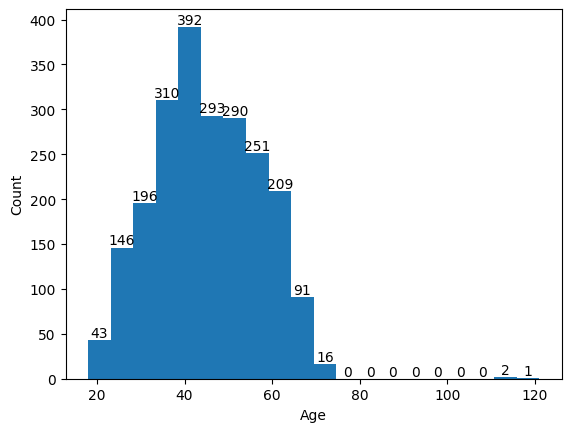

In [157]:
counts, bins, patches = plt.hist(df["Age"], bins=20)

for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(
        x,
        y,
        int(count),
        ha="center",
        va="bottom"
    )

plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

도표 결과 100세 이상은 이상치로 분류 해당 제거 필

In [158]:
df  = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

Income feature 분석

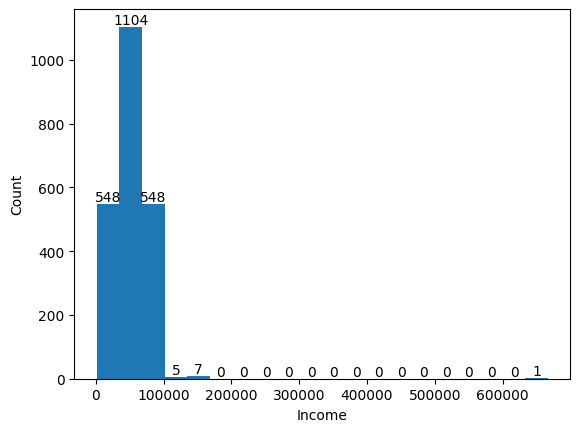

In [159]:
counts, bins, patches = plt.hist(df["Income"], bins=20)

for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(
        x,
        y,
        int(count),
        ha="center",
        va="bottom"
    )

plt.xlabel("Income")
plt.ylabel("Count")
plt.show()

극단적인 Income 이상치는 제거하고, Income 결측값은 train fold 안에서 median으로 대체한다.

In [160]:
df = df[df["Income"].isna() | (df["Income"] <= 300000)]

Education과 Marital_Status는 범주형 feature이므로, 전체 데이터에 미리 one-hot을 적용하지 않고 Pipeline 내부에서 encoding한다.

In [161]:
df["Education"] = df["Education"].astype("category")

In [162]:
rare_status = ["Alone", "Absurd", "YOLO"]

df["Marital_Status"] = df["Marital_Status"].replace(
    rare_status,
    "Other"
)

df["Marital_Status"] = df["Marital_Status"].fillna(
    df["Marital_Status"].mode()[0]
)
df["Marital_Status"] = df["Marital_Status"].astype("category")

결혼여부

In [163]:
df["HasPartner"] = df["Marital_Status"].isin(["Married", "Together"]).astype(int)
df["TotalChildren"] = df["Kidhome"] + df["Teenhome"]

In [164]:
feature_sets = {
    "Cold-start": [
        "Age",
        "Income",
        "Education",
        "Marital_Status",
        "Kidhome",
        "Teenhome",
    ],
    "Early-behavior": [
        "Age",
        "Income",
        "Education",
        "Marital_Status",
        "Kidhome",
        "Teenhome",
        "NumWebVisitsMonth",
    ],
    "Existing-customer": [
        "Age",
        "Income",
        "Education",
        "Marital_Status",
        "Kidhome",
        "Teenhome",
        "Recency",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases",
    ],
}

all_feature_cols = sorted({col for cols in feature_sets.values() for col in cols})
X = df[all_feature_cols].copy()

In [165]:
X.head()

,Age,Education,Income,Kidhome,Marital_Status,NumCatalogPurchases,NumStorePurchases,NumWebPurchases,NumWebVisitsMonth,Recency,Teenhome
0,57,Graduation,58138.0,0,Single,10,4,8,7,58,0
1,60,Graduation,46344.0,1,Single,1,2,1,5,38,1
2,49,Graduation,71613.0,0,Together,2,10,8,4,26,0
3,30,Graduation,26646.0,1,Together,0,4,2,6,26,0
4,33,PhD,58293.0,1,Married,3,6,5,5,94,0


전처리는 train/test split과 k-fold CV 내부에서만 fit되도록 Pipeline으로 구성한다.

1. positive skew가 큰 Income과 구매 횟수 변수에는 log1p 적용
2. numeric feature는 median imputation 후 StandardScaler 적용
3. categorical feature는 most-frequent imputation 후 OneHotEncoder 적용
4. 이 전체 전처리는 regression model과 하나의 Pipeline으로 묶어 data leakage를 방지함

In [166]:
log_numeric_candidates = [
    "Income",
    "NumWebVisitsMonth",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
]

standard_numeric_candidates = [
    "Age",
    "Kidhome",
    "Teenhome",
    "Recency",
]

categorical_candidates = [
    "Education",
    "Marital_Status",
]

In [167]:
def build_stage_preprocessor(stage_features):
    log_numeric_features = [
        col for col in log_numeric_candidates
        if col in stage_features
    ]
    standard_numeric_features = [
        col for col in standard_numeric_candidates
        if col in stage_features
    ]
    categorical_features = [
        col for col in categorical_candidates
        if col in stage_features
    ]

    transformers = []

    if log_numeric_features:
        transformers.append(
            (
                "log_num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                log_numeric_features,
            )
        )

    if standard_numeric_features:
        transformers.append(
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                standard_numeric_features,
            )
        )

    if categorical_features:
        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                categorical_features,
            )
        )

    return ColumnTransformer(transformers=transformers)

## preprocessing

예측해야 하는 y 생성: 제품군별 구매금액 자체가 아니라, 고객별 총 지출 대비 제품군별 비율을 예측한다.

In [168]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
]

total_spending = df[product_cols].sum(axis=1)
valid_target_index = total_spending[total_spending > 0].index

# Target: each product group's share of the customer's total spending.
y = df.loc[valid_target_index, product_cols].div(
    total_spending.loc[valid_target_index],
    axis=0,
)
X_model = X.loc[valid_target_index].copy()

In [169]:
y

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
0,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422
1,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222
2,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124
3,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340
4,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545
...,...,...,...,...,...,...
2235,0.528710,0.032066,0.135720,0.031320,0.087994,0.184191
2236,0.914414,0.000000,0.067568,0.000000,0.000000,0.018018
2237,0.731668,0.038678,0.174859,0.025786,0.009670,0.019339
2238,0.507711,0.035587,0.253855,0.094899,0.035587,0.072361


shape확인으로 row 개수 일치 확인

In [170]:
print(X_model.shape, y.shape)


(2236, 11) (2236, 6)


In [171]:
models = {
    "Multiple Linear Regression": LinearRegression(),
    "Polynomial Regression degree 2": Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("linear", LinearRegression()),
        ]
    ),
}


def normalize_predicted_ratios(raw_pred):
    pred = np.clip(np.asarray(raw_pred, dtype=float), 0, None)
    row_sums = pred.sum(axis=1, keepdims=True)
    return np.divide(pred, row_sums, out=np.zeros_like(pred), where=row_sums != 0)


def relative_preference_score(ratio_df, product_prior):
    score_df = ratio_df.div(product_prior, axis=1)
    score_df = score_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return score_df


train_index, test_index = train_test_split(
    X_model.index,
    test_size=0.2,
    random_state=42,
)

X_train_all = X_model.loc[train_index]
X_test_all = X_model.loc[test_index]
y_train = y.loc[train_index]
y_test = y.loc[test_index]

# Product prior is the train-set average product share.
# Recommendation uses predicted share / prior share, so popular categories like Wine
# do not win only because they are usually large spending categories.
product_prior = y_train.mean().replace(0, np.nan)
y_train_relative_score = relative_preference_score(y_train, product_prior)
y_test_relative_score = relative_preference_score(y_test, product_prior)

baseline_product = y_train_relative_score.idxmax(axis=1).mode()[0]
actual_relative_product = y_test_relative_score.idxmax(axis=1)
baseline_match_rate = (actual_relative_product == baseline_product).mean()
cv = KFold(n_splits=5, shuffle=True, random_state=42)

model_results = {}
model_summary = []

print("Baseline product:", baseline_product)
print("Baseline match rate:", baseline_match_rate)
print("Product prior:")
print(product_prior)

for stage_name, stage_features in feature_sets.items():
    X_stage = X_model[stage_features]
    X_train = X_train_all[stage_features]
    X_test = X_test_all[stage_features]

    for model_name, model in models.items():
        preprocessor = build_stage_preprocessor(stage_features)
        reg = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("model", model),
            ]
        )

        cv_scores = cross_val_score(reg, X_stage, y, cv=cv, scoring="r2")

        reg.fit(X_train, y_train)
        y_pred = normalize_predicted_ratios(reg.predict(X_test))
        y_pred_df = pd.DataFrame(y_pred, columns=product_cols, index=y_test.index)
        recommendation_score_df = relative_preference_score(y_pred_df, product_prior)

        actual_product = actual_relative_product
        recommended_product = recommendation_score_df.idxmax(axis=1)
        recommendation_match_rate = (actual_product == recommended_product).mean()

        test_r2 = r2_score(y_test, y_pred)
        test_mae = mean_absolute_error(y_test, y_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        result_key = f"{stage_name} | {model_name}"

        print(f"\n--- {result_key} ---")
        print("Features:", stage_features)
        print("5-fold CV R2:", cv_scores)
        print("Mean CV R2:", cv_scores.mean())
        print("Test R2:", test_r2)
        print("Test MAE:", test_mae)
        print("Test RMSE:", test_rmse)
        print("Relative recommendation match rate:", recommendation_match_rate)

        model_summary.append(
            {
                "Business Model": stage_name,
                "Regression Model": model_name,
                "Feature Count": len(stage_features),
                "Features": ", ".join(stage_features),
                "CV R2 Mean": cv_scores.mean(),
                "CV R2 Std": cv_scores.std(),
                "Test R2": test_r2,
                "Test MAE": test_mae,
                "Test RMSE": test_rmse,
                "Recommendation Match Rate": recommendation_match_rate,
                "Baseline Match Rate": baseline_match_rate,
                "Lift vs Baseline": recommendation_match_rate - baseline_match_rate,
            }
        )

        result_df = pd.concat(
            [
                y_test.add_prefix("ActualRatio_"),
                y_pred_df.add_prefix("PredictedRatio_"),
                y_test_relative_score.add_prefix("ActualRelativeScore_"),
                recommendation_score_df.add_prefix("RecommendationScore_"),
            ],
            axis=1,
        )
        result_df["Actual_Product"] = actual_product
        result_df["Recommended_Product"] = recommended_product
        result_df["Recommendation_Match"] = actual_product == recommended_product
        result_df["Banner_Ad_Order"] = recommendation_score_df.apply(
            lambda row: " > ".join(row.sort_values(ascending=False).index),
            axis=1,
        )
        result_df["Banner_Ad_Scores"] = recommendation_score_df.apply(
            lambda row: " | ".join(
                f"{product}:{score:.3f}"
                for product, score in row.sort_values(ascending=False).items()
            ),
            axis=1,
        )

        model_results[result_key] = {
            "business_model": stage_name,
            "regression_model": model_name,
            "features": stage_features,
            "model": reg,
            "predictions": result_df,
        }

Baseline product: MntWines
Baseline match rate: 0.29910714285714285
Product prior:
MntWines            0.458442
MntFruits           0.049295
MntMeatProducts     0.247679
MntFishProducts     0.071233
MntSweetProducts    0.051369
MntGoldProds        0.121982
dtype: float64

--- Cold-start | Multiple Linear Regression ---
Features: ['Age', 'Income', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome']
5-fold CV R2: [0.28047718 0.23168258 0.24862569 0.27581808 0.23667321]
Mean CV R2: 0.2546553472106322
Test R2: 0.28099993491348496
Test MAE: 0.06872981681461117
Test RMSE: 0.09616083849139877
Relative recommendation match rate: 0.3705357142857143

--- Cold-start | Polynomial Regression degree 2 ---
Features: ['Age', 'Income', 'Education', 'Marital_Status', 'Kidhome', 'Teenhome']
5-fold CV R2: [0.25461623 0.21371602 0.24615947 0.25971444 0.23865041]
Mean CV R2: 0.24257131450166963
Test R2: 0.259045902261477
Test MAE: 0.06870292128400385
Test RMSE: 0.09753437830515917
Relative recommendation 

,Business Model,Regression Model,Feature Count,Features,CV R2 Mean,CV R2 Std,Test R2,Test MAE,Test RMSE,Recommendation Match Rate,Baseline Match Rate,Lift vs Baseline
5,Existing-customer,Polynomial Regression degree 2,10,"Age, Income, Education, Marital_Status, Kidhom...",0.226176,0.021212,0.245043,0.068909,0.098599,0.404018,0.299107,0.104911
4,Existing-customer,Multiple Linear Regression,10,"Age, Income, Education, Marital_Status, Kidhom...",0.266239,0.020145,0.294800,0.067938,0.094886,0.401786,0.299107,0.102679
3,Early-behavior,Polynomial Regression degree 2,7,"Age, Income, Education, Marital_Status, Kidhom...",0.250784,0.018688,0.254903,0.067745,0.096394,0.401786,0.299107,0.102679
1,Cold-start,Polynomial Regression degree 2,6,"Age, Income, Education, Marital_Status, Kidhom...",0.242571,0.016124,0.259046,0.068703,0.097534,0.397321,0.299107,0.098214
2,Early-behavior,Multiple Linear Regression,7,"Age, Income, Education, Marital_Status, Kidhom...",0.274130,0.016715,0.293637,0.067315,0.094389,0.375000,0.299107,0.075893
0,Cold-start,Multiple Linear Regression,6,"Age, Income, Education, Marital_Status, Kidhom...",0.254655,0.020010,0.281000,0.068730,0.096161,0.370536,0.299107,0.071429


,Business Model,Regression Model,Feature Count,Features,CV R2 Mean,CV R2 Std,Test R2,Test MAE,Test RMSE,Recommendation Match Rate,Baseline Match Rate,Lift vs Baseline
1,Cold-start,Polynomial Regression degree 2,6,"Age, Income, Education, Marital_Status, Kidhom...",0.242571,0.016124,0.259046,0.068703,0.097534,0.397321,0.299107,0.098214
3,Early-behavior,Polynomial Regression degree 2,7,"Age, Income, Education, Marital_Status, Kidhom...",0.250784,0.018688,0.254903,0.067745,0.096394,0.401786,0.299107,0.102679
5,Existing-customer,Polynomial Regression degree 2,10,"Age, Income, Education, Marital_Status, Kidhom...",0.226176,0.021212,0.245043,0.068909,0.098599,0.404018,0.299107,0.104911


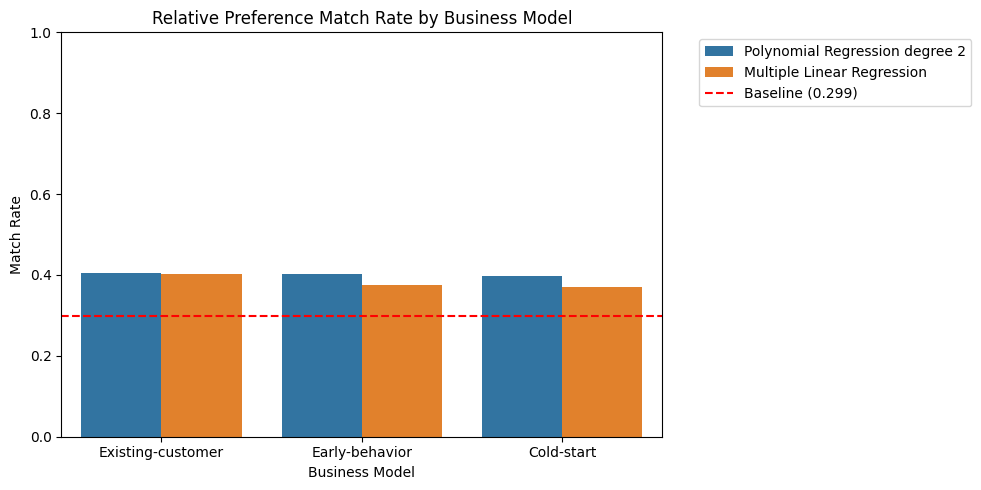

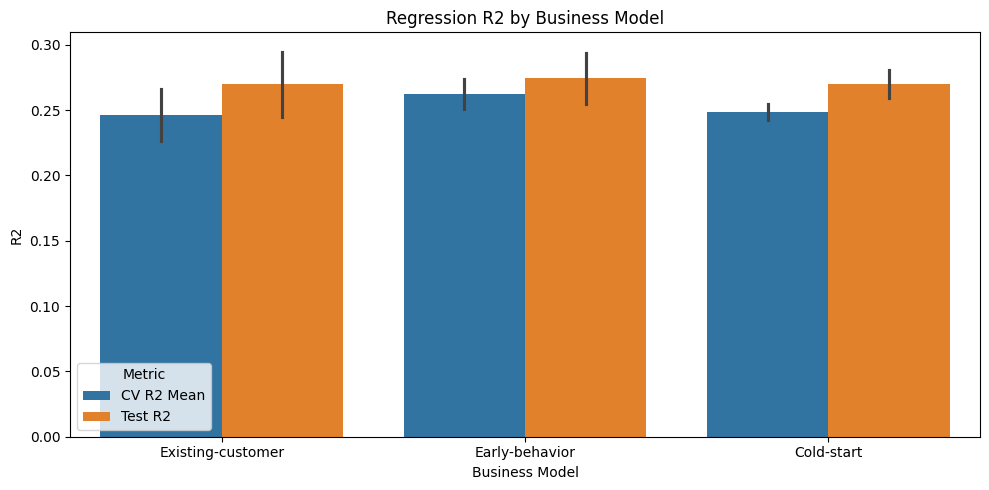

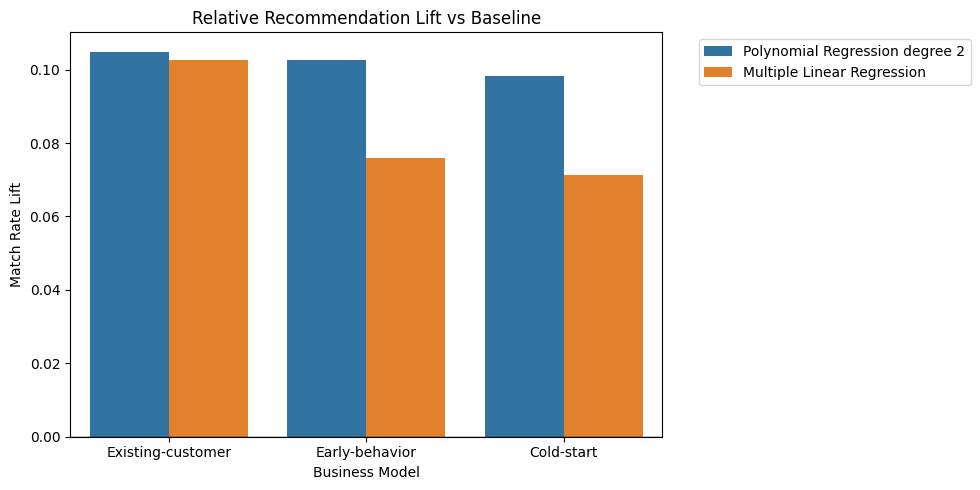

Final model selected: Existing-customer | Polynomial Regression degree 2


,Actual_Product,Recommended_Product,Recommendation_Match,Banner_Ad_Order,Banner_Ad_Scores
1755,MntFruits,MntGoldProds,False,MntGoldProds > MntFruits > MntFishProducts > M...,MntGoldProds:2.994 | MntFruits:2.786 | MntFish...
370,MntSweetProducts,MntFruits,False,MntFruits > MntFishProducts > MntGoldProds > M...,MntFruits:2.048 | MntFishProducts:2.014 | MntG...
1250,MntMeatProducts,MntWines,False,MntWines > MntMeatProducts > MntFruits > MntSw...,MntWines:1.216 | MntMeatProducts:1.118 | MntFr...
852,MntMeatProducts,MntMeatProducts,True,MntMeatProducts > MntFishProducts > MntFruits ...,MntMeatProducts:1.486 | MntFishProducts:1.362 ...
1750,MntWines,MntWines,True,MntWines > MntGoldProds > MntSweetProducts > M...,MntWines:1.567 | MntGoldProds:0.599 | MntSweet...
100,MntWines,MntFruits,False,MntFruits > MntSweetProducts > MntGoldProds > ...,MntFruits:2.197 | MntSweetProducts:1.627 | Mnt...
134,MntWines,MntWines,True,MntWines > MntMeatProducts > MntGoldProds > Mn...,MntWines:1.427 | MntMeatProducts:0.831 | MntGo...
1521,MntMeatProducts,MntFishProducts,False,MntFishProducts > MntMeatProducts > MntFruits ...,MntFishProducts:1.580 | MntMeatProducts:1.279 ...
1350,MntMeatProducts,MntMeatProducts,True,MntMeatProducts > MntWines > MntFishProducts >...,MntMeatProducts:1.254 | MntWines:1.243 | MntFi...
300,MntGoldProds,MntGoldProds,True,MntGoldProds > MntSweetProducts > MntWines > M...,MntGoldProds:1.520 | MntSweetProducts:1.150 | ...


Recommended_Product,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Actual_Product,,,,,,
MntWines,86,5,13,5,8,17
MntFruits,10,16,8,6,9,11
MntMeatProducts,25,6,28,4,4,13
MntFishProducts,12,5,10,16,7,11
MntSweetProducts,15,7,9,11,6,9
MntGoldProds,9,4,4,6,4,29


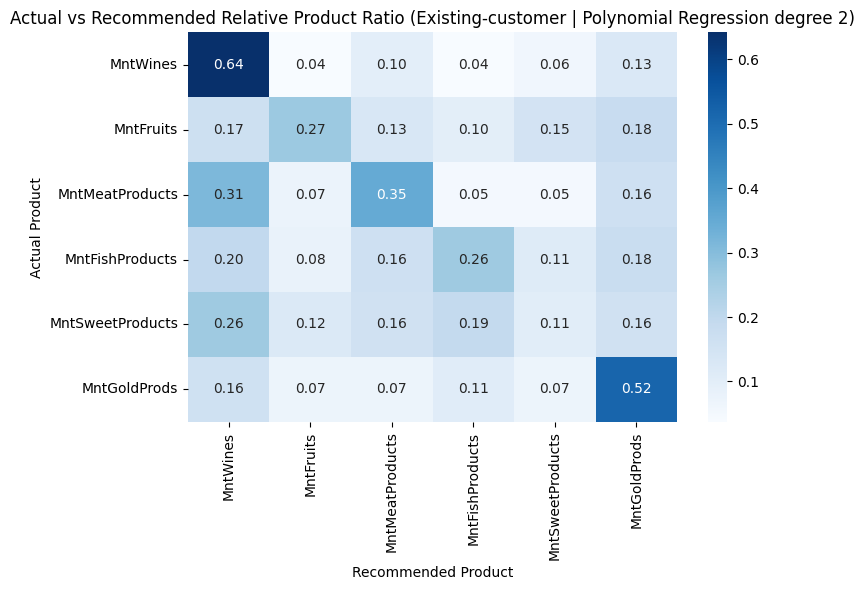

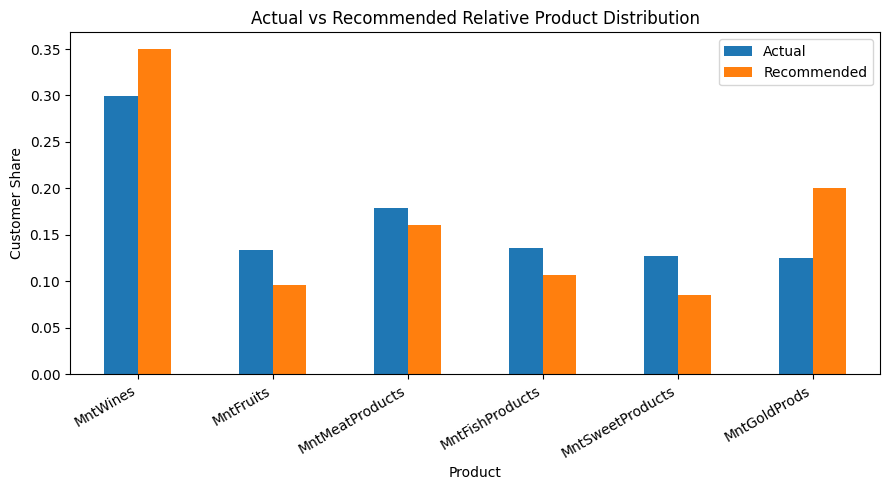

In [172]:
model_summary_df = pd.DataFrame(model_summary).sort_values(
    by=["Recommendation Match Rate", "Test R2"],
    ascending=False,
)
display(model_summary_df)

best_by_business_model = model_summary_df.sort_values(
    by=["Business Model", "Recommendation Match Rate", "Test R2"],
    ascending=[True, False, False],
).groupby("Business Model", as_index=False).head(1)

display(best_by_business_model)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=model_summary_df,
    x="Business Model",
    y="Recommendation Match Rate",
    hue="Regression Model",
)
plt.axhline(
    baseline_match_rate,
    color="red",
    linestyle="--",
    label=f"Baseline ({baseline_match_rate:.3f})",
)
plt.title("Relative Preference Match Rate by Business Model")
plt.xlabel("Business Model")
plt.ylabel("Match Rate")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

r2_plot_df = model_summary_df.melt(
    id_vars=["Business Model", "Regression Model"],
    value_vars=["CV R2 Mean", "Test R2"],
    var_name="Metric",
    value_name="R2",
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=r2_plot_df,
    x="Business Model",
    y="R2",
    hue="Metric",
)
plt.title("Regression R2 by Business Model")
plt.xlabel("Business Model")
plt.ylabel("R2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=model_summary_df,
    x="Business Model",
    y="Lift vs Baseline",
    hue="Regression Model",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Relative Recommendation Lift vs Baseline")
plt.xlabel("Business Model")
plt.ylabel("Match Rate Lift")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

final_result_key = (
    model_summary_df.iloc[0]["Business Model"]
    + " | "
    + model_summary_df.iloc[0]["Regression Model"]
)
final_predictions = model_results[final_result_key]["predictions"]

print("Final model selected:", final_result_key)
display(final_predictions[[
    "Actual_Product",
    "Recommended_Product",
    "Recommendation_Match",
    "Banner_Ad_Order",
    "Banner_Ad_Scores",
]].head(10))

confusion_counts = pd.crosstab(
    final_predictions["Actual_Product"],
    final_predictions["Recommended_Product"],
).reindex(index=product_cols, columns=product_cols, fill_value=0)

display(confusion_counts)

confusion_rate = pd.crosstab(
    final_predictions["Actual_Product"],
    final_predictions["Recommended_Product"],
    normalize="index",
).reindex(index=product_cols, columns=product_cols, fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_rate, annot=True, fmt=".2f", cmap="Blues")
plt.title(f"Actual vs Recommended Relative Product Ratio ({final_result_key})")
plt.xlabel("Recommended Product")
plt.ylabel("Actual Product")
plt.tight_layout()
plt.show()

product_distribution_df = pd.DataFrame(
    {
        "Actual": final_predictions["Actual_Product"].value_counts(normalize=True),
        "Recommended": final_predictions["Recommended_Product"].value_counts(normalize=True),
    }
).reindex(product_cols).fillna(0)

product_distribution_df.plot(kind="bar", figsize=(9, 5))
plt.title("Actual vs Recommended Relative Product Distribution")
plt.xlabel("Product")
plt.ylabel("Customer Share")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

모델은 고객의 가입 단계별로 사용할 수 있는 feature를 나누어 6개 제품군의 구매 비율을 multi-output regression으로 예측한다.

예측된 구매 비율을 그대로 argmax하면 Wine처럼 원래 지출 비중이 큰 제품군에 추천이 쏠릴 수 있다. 따라서 최종 추천 점수는 `예측 제품군 비율 / train set 평균 제품군 비율`로 계산한다.

이 추천 점수는 “전체 평균 대비 이 고객에게 상대적으로 더 강하게 나타나는 제품군 선호도”를 의미한다. 최종 광고 품목은 이 상대 선호 점수가 가장 높은 제품군으로 선택한다.

In [173]:
banner_output_cols = [
    "Actual_Product",
    "Recommended_Product",
    "Recommendation_Match",
    "Banner_Ad_Order",
    "Banner_Ad_Scores",
]

banner_recommendation_output = final_predictions[banner_output_cols].copy()

print("Banner ad display order sample")
display(banner_recommendation_output.head(10))

sample_customer_id = banner_recommendation_output.index[0]
sample_order = banner_recommendation_output.loc[sample_customer_id, "Banner_Ad_Order"].split(" > ")

print(f"\nSample customer index: {sample_customer_id}")
print("Banner ad display order:")
for rank, product in enumerate(sample_order, start=1):
    print(f"{rank}. {product}")

score_cols = [f"RecommendationScore_{col}" for col in product_cols]
sample_score_table = (
    final_predictions.loc[[sample_customer_id], score_cols]
    .T
    .reset_index()
)
sample_score_table.columns = ["Product", "RecommendationScore"]
sample_score_table["Product"] = sample_score_table["Product"].str.replace(
    "RecommendationScore_",
    "",
    regex=False,
)
sample_score_table = sample_score_table.sort_values(
    "RecommendationScore",
    ascending=False,
)

display(sample_score_table)

Banner ad display order sample


,Actual_Product,Recommended_Product,Recommendation_Match,Banner_Ad_Order,Banner_Ad_Scores
1755,MntFruits,MntGoldProds,False,MntGoldProds > MntFruits > MntFishProducts > M...,MntGoldProds:2.994 | MntFruits:2.786 | MntFish...
370,MntSweetProducts,MntFruits,False,MntFruits > MntFishProducts > MntGoldProds > M...,MntFruits:2.048 | MntFishProducts:2.014 | MntG...
1250,MntMeatProducts,MntWines,False,MntWines > MntMeatProducts > MntFruits > MntSw...,MntWines:1.216 | MntMeatProducts:1.118 | MntFr...
852,MntMeatProducts,MntMeatProducts,True,MntMeatProducts > MntFishProducts > MntFruits ...,MntMeatProducts:1.486 | MntFishProducts:1.362 ...
1750,MntWines,MntWines,True,MntWines > MntGoldProds > MntSweetProducts > M...,MntWines:1.567 | MntGoldProds:0.599 | MntSweet...
100,MntWines,MntFruits,False,MntFruits > MntSweetProducts > MntGoldProds > ...,MntFruits:2.197 | MntSweetProducts:1.627 | Mnt...
134,MntWines,MntWines,True,MntWines > MntMeatProducts > MntGoldProds > Mn...,MntWines:1.427 | MntMeatProducts:0.831 | MntGo...
1521,MntMeatProducts,MntFishProducts,False,MntFishProducts > MntMeatProducts > MntFruits ...,MntFishProducts:1.580 | MntMeatProducts:1.279 ...
1350,MntMeatProducts,MntMeatProducts,True,MntMeatProducts > MntWines > MntFishProducts >...,MntMeatProducts:1.254 | MntWines:1.243 | MntFi...
300,MntGoldProds,MntGoldProds,True,MntGoldProds > MntSweetProducts > MntWines > M...,MntGoldProds:1.520 | MntSweetProducts:1.150 | ...



Sample customer index: 1755
Banner ad display order:
1. MntGoldProds
2. MntFruits
3. MntFishProducts
4. MntSweetProducts
5. MntMeatProducts
6. MntWines


,Product,RecommendationScore
5,MntGoldProds,2.993786
1,MntFruits,2.785937
3,MntFishProducts,2.490347
4,MntSweetProducts,1.784247
2,MntMeatProducts,0.486507
0,MntWines,0.235429


고객이 가장 많이 살 품목 순서가 아니라, 평균 고객 대비 이 고객에게 더 차별적으로 반응할 가능성이 높은 광고 품목 순서

분석 질문 정리
s
1. 같은 연봉대에서 어떤 제품군을 추천하는가: IncomeGroup별 추천 분포로 확인
2. 과거 구매 리스트 기준 추천: Mnt...는 target이므로 feature로 넣지 않음. 대신 구매 채널 횟수와 고객 속성으로 선호 비율을 예측
3. 가족 유무에 따른 추천: HasPartner와 TotalChildren으로 FamilySegment를 만들어 확인
4. 직장 유무: 이 Kaggle dataset에는 직업/고용 상태 feature가 없어 분석에서 제외
5. 최종 추천 품목: RecommendationScore가 가장 높은 제품군
6. 증강: 과제 요구사항에는 필수가 아니며, 현재는 실제 관측 데이터 기반 regression 결과를 우선 사용